# Baseline 3: Train from scratch - No Attention

In [ ]:
# Cài đặt phiên bản torch và torchtext tương thích
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0

In [ ]:
import os
from google.colab import drive

print("Đang kết nối với Google Drive...")
drive.mount('/content/drive')

Đang kết nối với Google Drive...
Mounted at /content/drive


# Baseline 3: Mạng tự xây dựng (Train from Scratch) - Không có Attention
**Dữ liệu:** VQA v2 (Dùng lại thư mục `/content/VQA_v2/` đã tải từ các baseline trước).
**Kiến trúc:** Custom CNN (Tự build bằng Conv2d, không dùng Pretrained) + BiLSTM + LSTM Decoder.

Mục tiêu của Baseline này là để làm đối chứng (Ablation Study), cho thấy việc sử dụng một mạng CNN khởi tạo ngẫu nhiên từ đầu sẽ hội tụ chậm và đạt độ chính xác thấp hơn so với việc dùng Pretrained Model (ResNet) như ở Baseline 1.

In [ ]:
import torchtext
torchtext.disable_torchtext_deprecation_warning()
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import os
import random
import json
import numpy as np
import spacy
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchtext.vocab import build_vocab_from_iterator
from tqdm.auto import tqdm

# Cố định Seed để đảm bảo tái lập kết quả
def set_seed(seed=59):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


In [ ]:
%%bash
# Tạo thư mục chứa dữ liệu
mkdir -p /content/VQA_v2/Images
mkdir -p /content/VQA_v2/Text

# 1. Tải và giải nén MS COCO Val 2014 Images
echo "Đang tải MS COCO Val2014 Images..."
# Tải file (nếu chưa có)
wget -nc -q http://images.cocodataset.org/zips/val2014.zip
echo "Đang giải nén ảnh (Tự động ghi đè nếu đã tồn tại)..."
# Thêm -o để tự động overwrite không cần hỏi
unzip -q -o val2014.zip -d /content/VQA_v2/Images/
rm -f val2014.zip

# 2. Tải và giải nén VQA v2 Questions (Val)
echo "Đang tải VQA v2 Val Questions..."
wget -nc -q https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Questions_Val_mscoco.zip
echo "Đang giải nén Questions..."
unzip -q -o v2_Questions_Val_mscoco.zip -d /content/VQA_v2/Text/
rm -f v2_Questions_Val_mscoco.zip

# 3. Tải và giải nén VQA v2 Annotations (Val)
echo "Đang tải VQA v2 Val Annotations..."
wget -nc -q https://s3.amazonaws.com/cvmlp/vqa/mscoco/vqa/v2_Annotations_Val_mscoco.zip
echo "Đang giải nén Annotations..."
unzip -q -o v2_Annotations_Val_mscoco.zip -d /content/VQA_v2/Text/
rm -f v2_Annotations_Val_mscoco.zip

echo "Hoàn tất tải và giải nén dữ liệu!"

Đang tải MS COCO Val2014 Images...
Đang giải nén ảnh (Tự động ghi đè nếu đã tồn tại)...
Đang tải VQA v2 Val Questions...
Đang giải nén Questions...
Đang tải VQA v2 Val Annotations...
Đang giải nén Annotations...
Hoàn tất tải và giải nén dữ liệu!


In [ ]:
!python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

def load_vqa_v2_data(img_dir, questions_path, annotations_path, split='train', limit=None):
    with open(questions_path, 'r') as f:
        q_data = json.load(f)['questions']
    with open(annotations_path, 'r') as f:
        a_data = json.load(f)['annotations']

    if limit:
        q_data = q_data[:limit]
        a_data = a_data[:limit]

    dataset = []
    for q, a in zip(q_data, a_data):
        img_id = q['image_id']
        img_name = f"COCO_val2014_{str(img_id).zfill(12)}.jpg"
        img_path = os.path.join(img_dir, img_name)

        if os.path.exists(img_path):
            question = q['question']
            answer = a['multiple_choice_answer']
            dataset.append({'image_path': img_path, 'question': question, 'answer': answer})
    return dataset

# Giới hạn 20000 mẫu để train nhanh giống Baseline trước
val_data = load_vqa_v2_data(
    '/content/VQA_v2/Images/val2014',
    '/content/VQA_v2/Text/v2_OpenEnded_mscoco_val2014_questions.json',
    '/content/VQA_v2/Text/v2_mscoco_val2014_annotations.json',
    split='val', limit=20000
)

random.shuffle(val_data)
train_size = int(0.8 * len(val_data))
train_data_split = val_data[:train_size]
val_data_split = val_data[train_size:]

def tokenize(text):
    return [tok.text.lower() for tok in nlp.tokenizer(text)]

def yield_tokens(data):
    for item in data:
        yield tokenize(item['question'])
        yield tokenize(item['answer'])

vocab = build_vocab_from_iterator(yield_tokens(train_data_split), specials=['<pad>', '<sos>', '<eos>', '<unk>'])
vocab.set_default_index(vocab['<unk>'])

PAD_IDX, SOS_IDX, EOS_IDX = vocab['<pad>'], vocab['<sos>'], vocab['<eos>']

class VQASeq2SeqDataset(Dataset):
    def __init__(self, data, vocab, transform=None, max_q_len=15, max_a_len=5):
        self.data = data
        self.vocab = vocab
        self.transform = transform
        self.max_q_len = max_q_len
        self.max_a_len = max_a_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = Image.open(item['image_path']).convert('RGB')
        if self.transform: image = self.transform(image)

        q_tokens = tokenize(item['question'])
        q_indices = [self.vocab[token] for token in q_tokens][:self.max_q_len]
        q_indices += [PAD_IDX] * max(0, self.max_q_len - len(q_indices))

        a_tokens = tokenize(item['answer'])
        a_indices = [SOS_IDX] + [self.vocab[token] for token in a_tokens][:self.max_a_len-2] + [EOS_IDX]
        a_indices += [PAD_IDX] * max(0, self.max_a_len - len(a_indices))

        return image, torch.tensor(q_indices), torch.tensor(a_indices)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = VQASeq2SeqDataset(train_data_split, vocab, transform)
val_dataset = VQASeq2SeqDataset(val_data_split, vocab, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Vocab size: {len(vocab)} | Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 98.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Vocab size: 5141 | Train size: 16000 | Val size: 4000


In [ ]:
# 1. Tự xây dựng kiến trúc CNN thay vì dùng ResNet (Custom CNN)
class CustomCNN(nn.Module):
    def __init__(self, embed_size=512):
        super(CustomCNN, self).__init__()
        # Input: 3 kênh (RGB), kích thước 224x224
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # -> 112x112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # -> 56x56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # -> 28x28

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # -> 14x14

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)) # Global Average Pooling -> 1x1
        )
        self.fc = nn.Linear(512, embed_size)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1) # Duỗi thành vector [Batch, 512]
        x = self.fc(x)
        return x

# 2. Kiến trúc Seq2Seq không có Attention
class VQA_CustomCNN_LSTM_NoAttention(nn.Module):
    def __init__(self, vocab_size, embed_size=256, hidden_size=512):
        super(VQA_CustomCNN_LSTM_NoAttention, self).__init__()

        # Image Encoder
        self.cnn = CustomCNN(embed_size=embed_size)

        # Text Encoder
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.q_bilstm = nn.LSTM(embed_size, hidden_size // 2, bidirectional=True, batch_first=True)

        # Fusion
        self.fusion_fc = nn.Linear(embed_size + hidden_size, hidden_size)

        # Text Decoder
        self.decoder_lstm = nn.LSTM(embed_size + hidden_size, hidden_size, batch_first=True)
        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def forward(self, images, questions, answers):
        batch_size = images.size(0)

        # 1. Trích xuất vector ảnh
        img_features = self.cnn(images) # [Batch, embed_size]

        # 2. Trích xuất vector câu hỏi
        q_embed = self.embedding(questions)
        _, (q_hidden, _) = self.q_bilstm(q_embed)
        q_features = torch.cat((q_hidden[-2], q_hidden[-1]), dim=1) # [Batch, hidden_size]

        # 3. Kết hợp (Late Fusion)
        combined = torch.cat((img_features, q_features), dim=1)
        context_vector = torch.relu(self.fusion_fc(combined)) # [Batch, hidden_size]

        # 4. Decoder (Auto-regressive sinh từ)
        ans_embed = self.embedding(answers)
        seq_len = ans_embed.size(1)

        logits = torch.zeros(batch_size, seq_len, self.fc_out.out_features).to(device)

        decoder_hidden = context_vector.unsqueeze(0)
        decoder_cell = torch.zeros_like(decoder_hidden)

        for t in range(seq_len):
            # Nối Context Vector vào từng timestep
            context_expanded = context_vector.unsqueeze(1)
            step_input = torch.cat((ans_embed[:, t, :].unsqueeze(1), context_expanded), dim=2)

            out, (decoder_hidden, decoder_cell) = self.decoder_lstm(step_input, (decoder_hidden, decoder_cell))
            logits[:, t, :] = self.fc_out(out.squeeze(1))

        return logits

In [ ]:
model = VQA_CustomCNN_LSTM_NoAttention(vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def fit_model(model, train_loader, val_loader, criterion, optimizer, epochs=20):
    train_losses, val_losses, val_accuracies = [], [], []

    for epoch in range(epochs):
        # --- TRAIN ---
        model.train()
        total_loss = 0
        for images, questions, answers in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, questions, answers = images.to(device), questions.to(device), answers.to(device)

            ans_input = answers[:, :-1]  # Bỏ token cuối
            ans_target = answers[:, 1:]  # Dịch phải 1 bước (Ground Truth)

            optimizer.zero_grad()
            logits = model(images, questions, ans_input)

            logits = logits.reshape(-1, logits.size(-1))
            ans_target = ans_target.reshape(-1)

            loss = criterion(logits, ans_target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        # --- VALIDATE ---
        model.eval()
        val_loss, correct_matches, total_samples = 0, 0, 0

        with torch.no_grad():
            for images, questions, answers in val_loader:
                images, questions, answers = images.to(device), questions.to(device), answers.to(device)

                ans_input = answers[:, :-1]
                ans_target = answers[:, 1:]

                logits = model(images, questions, ans_input)

                loss = criterion(logits.reshape(-1, logits.size(-1)), ans_target.reshape(-1))
                val_loss += loss.item()

                predictions = logits.argmax(dim=-1)

                for i in range(answers.size(0)):
                    pred_seq = []
                    for token in predictions[i]:
                        if token.item() == EOS_IDX: break
                        pred_seq.append(token.item())

                    target_seq = []
                    for token in ans_target[i]:
                        if token.item() == EOS_IDX: break
                        target_seq.append(token.item())

                    if pred_seq == target_seq:
                        correct_matches += 1
                    total_samples += 1

        val_losses.append(val_loss / len(val_loader))
        accuracy = (correct_matches / total_samples) * 100
        val_accuracies.append(accuracy)

        print(f"Epoch {epoch+1} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {accuracy:.2f}%")

    return train_losses, val_losses, val_accuracies

train_losses, val_losses, val_accuracies = fit_model(model, train_loader, val_loader, criterion, optimizer, epochs=20)

Epoch 1/20:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 3.0286 | Val Loss: 2.3329 | Val Acc: 24.10%


Epoch 2/20:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 2.2520 | Val Loss: 2.1915 | Val Acc: 25.42%


Epoch 3/20:   0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch 18 | Train Loss: 1.3648 | Val Loss: 2.1013 | Val Acc: 28.43%


Epoch 19/20:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 19 | Train Loss: 1.3204 | Val Loss: 2.1162 | Val Acc: 28.10%


Epoch 20/20:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 20 | Train Loss: 1.2785 | Val Loss: 2.1388 | Val Acc: 28.30%


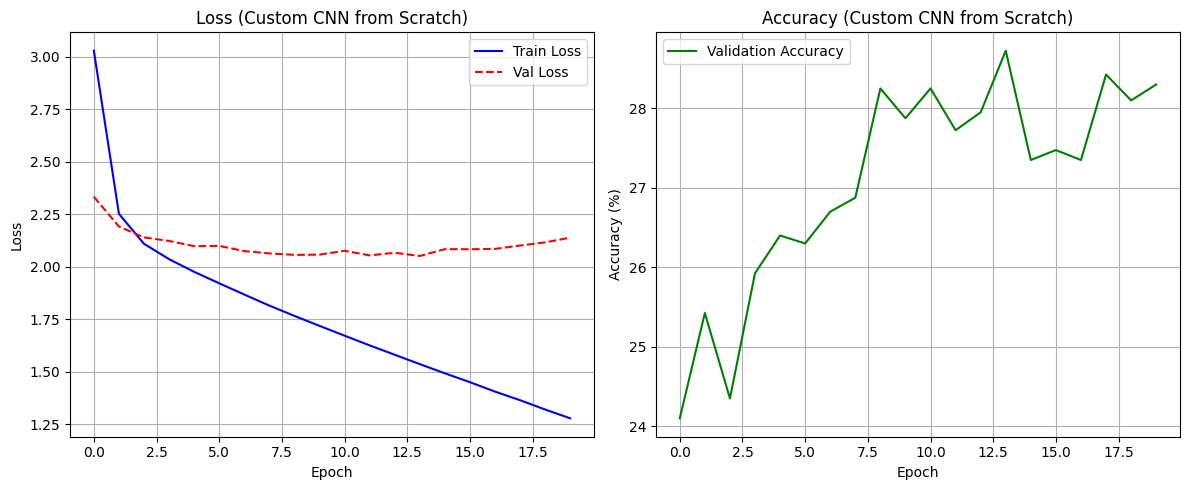

Đã lưu mô hình tại: /content/drive/MyDrive/VQA_Models/vqa_baseline3_from_scratch.pth


In [ ]:
# Vẽ biểu đồ
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='red', linestyle='--')
plt.title('Loss (Custom CNN from Scratch)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='green')
plt.title('Accuracy (Custom CNN from Scratch)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Lưu model
save_dir = '/content/drive/MyDrive/VQA_Models'
os.makedirs(save_dir, exist_ok=True)
model_path = os.path.join(save_dir, 'vqa_baseline3_from_scratch.pth')

torch.save({
    'epoch': 20,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, model_path)
print(f"Đã lưu mô hình tại: {model_path}")

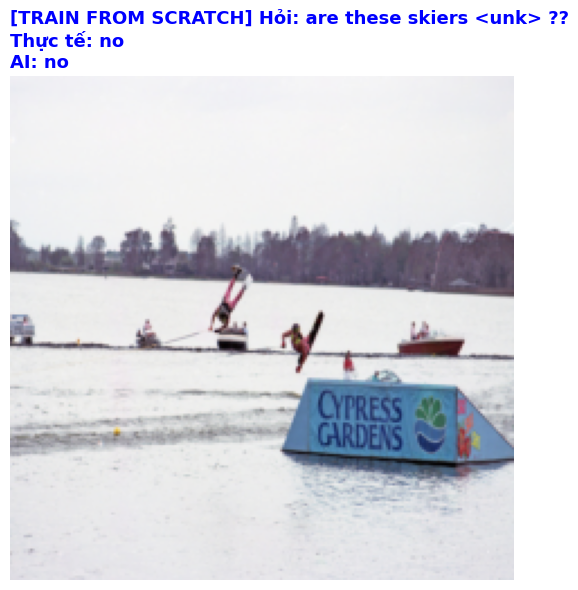

In [ ]:
def demo_baseline3_with_temperature(model, dataset, vocab, index=None, max_len=5, temperature=1.5):
    model.eval()
    if index is None: index = random.randint(0, len(dataset) - 1)

    img_tensor, q_tensor, ans_tensor = dataset[index]
    img_input = img_tensor.unsqueeze(0).to(device)
    q_input = q_tensor.unsqueeze(0).to(device)

    def get_word(idx):
        try: return vocab.lookup_token(idx)
        except: return '<unk>'

    with torch.no_grad():
        ans_in = torch.tensor([[SOS_IDX]]).to(device)
        pred_words = []

        for step in range(max_len):
            logits = model(img_input, q_input, ans_in)

            # Temperature Scaling
            next_word_logits = logits[:, -1, :]
            probs = torch.softmax(next_word_logits / temperature, dim=-1)
            next_word_idx = torch.multinomial(probs, num_samples=1).item()

            if next_word_idx == EOS_IDX: break

            pred_words.append(get_word(next_word_idx))
            ans_in = torch.cat([ans_in, torch.tensor([[next_word_idx]]).to(device)], dim=1)

        pred_sentence = " ".join(pred_words)
        if not pred_sentence.strip(): pred_sentence = "<rỗng>"

    q_text = " ".join([get_word(idx) for idx in q_tensor.tolist() if get_word(idx) not in ['<pad>', '<sos>', '<eos>']])
    true_ans = " ".join([get_word(idx) for idx in ans_tensor.tolist() if get_word(idx) not in ['<pad>', '<sos>', '<eos>']])

    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip((np.array([0.229, 0.224, 0.225]) * img_np + np.array([0.485, 0.456, 0.406])), 0, 1)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_np)
    color = 'blue' if pred_sentence == true_ans else 'red'
    plt.title(f"[TRAIN FROM SCRATCH] Hỏi: {q_text}?\nThực tế: {true_ans}\nAI: {pred_sentence}",
              fontsize=13, color=color, fontweight='bold', loc='left')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Chạy thử demo
demo_baseline3_with_temperature(model, val_loader.dataset, vocab, temperature=1.0)